<a href="https://www.kaggle.com/code/lalit7881/logic-for-each-arc-task-eda?scriptVersionId=312977885" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/arc_explanations.csv
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/arc_explanations.json
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task122.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task393.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task293.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task053.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task199.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task062.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task070.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task120.onnx
/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/submission/task399.onnx
/kaggle/input/datasets/karnakbaevarth

## Loading dataset

In [2]:
import os
import json
BASE_PATH = "/kaggle/input/datasets/karnakbaevarthur/logic-for-each-arc-task/"

In [3]:
csv_path = os.path.join(BASE_PATH, "arc_explanations.csv")
df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(400, 2)


,Task_ID,Short_Rule
0,task001,The transformation creates a 9x9 output grid b...
1,task002,Identify all interior regions completely surro...
2,task003,The transformation duplicates the input grid v...
3,task004,Shift each object (connected group of same-col...
4,task005,"For each distinct non-zero color in the input,..."


In [4]:
print(df.columns)
print(df.info())
print(df.describe(include='all'))

Index(['Task_ID', 'Short_Rule'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Task_ID     400 non-null    object
 1   Short_Rule  400 non-null    object
dtypes: object(2)
memory usage: 6.4+ KB
None
        Task_ID                                         Short_Rule
count       400                                                400
unique      400                                                400
top     task384  Identify all connected components of color 4 i...
freq          1                                                  1


In [5]:
df.columns

Index(['Task_ID', 'Short_Rule'], dtype='object')

In [6]:
df.nunique()

Task_ID       400
Short_Rule    400
dtype: int64

## EDA

In [7]:
from collections import Counter
plt.style.use('ggplot')

In [8]:
print("Total Tasks:", df.shape[0])
print("Unique Rules:", df['Short_Rule'].nunique())

Total Tasks: 400
Unique Rules: 400


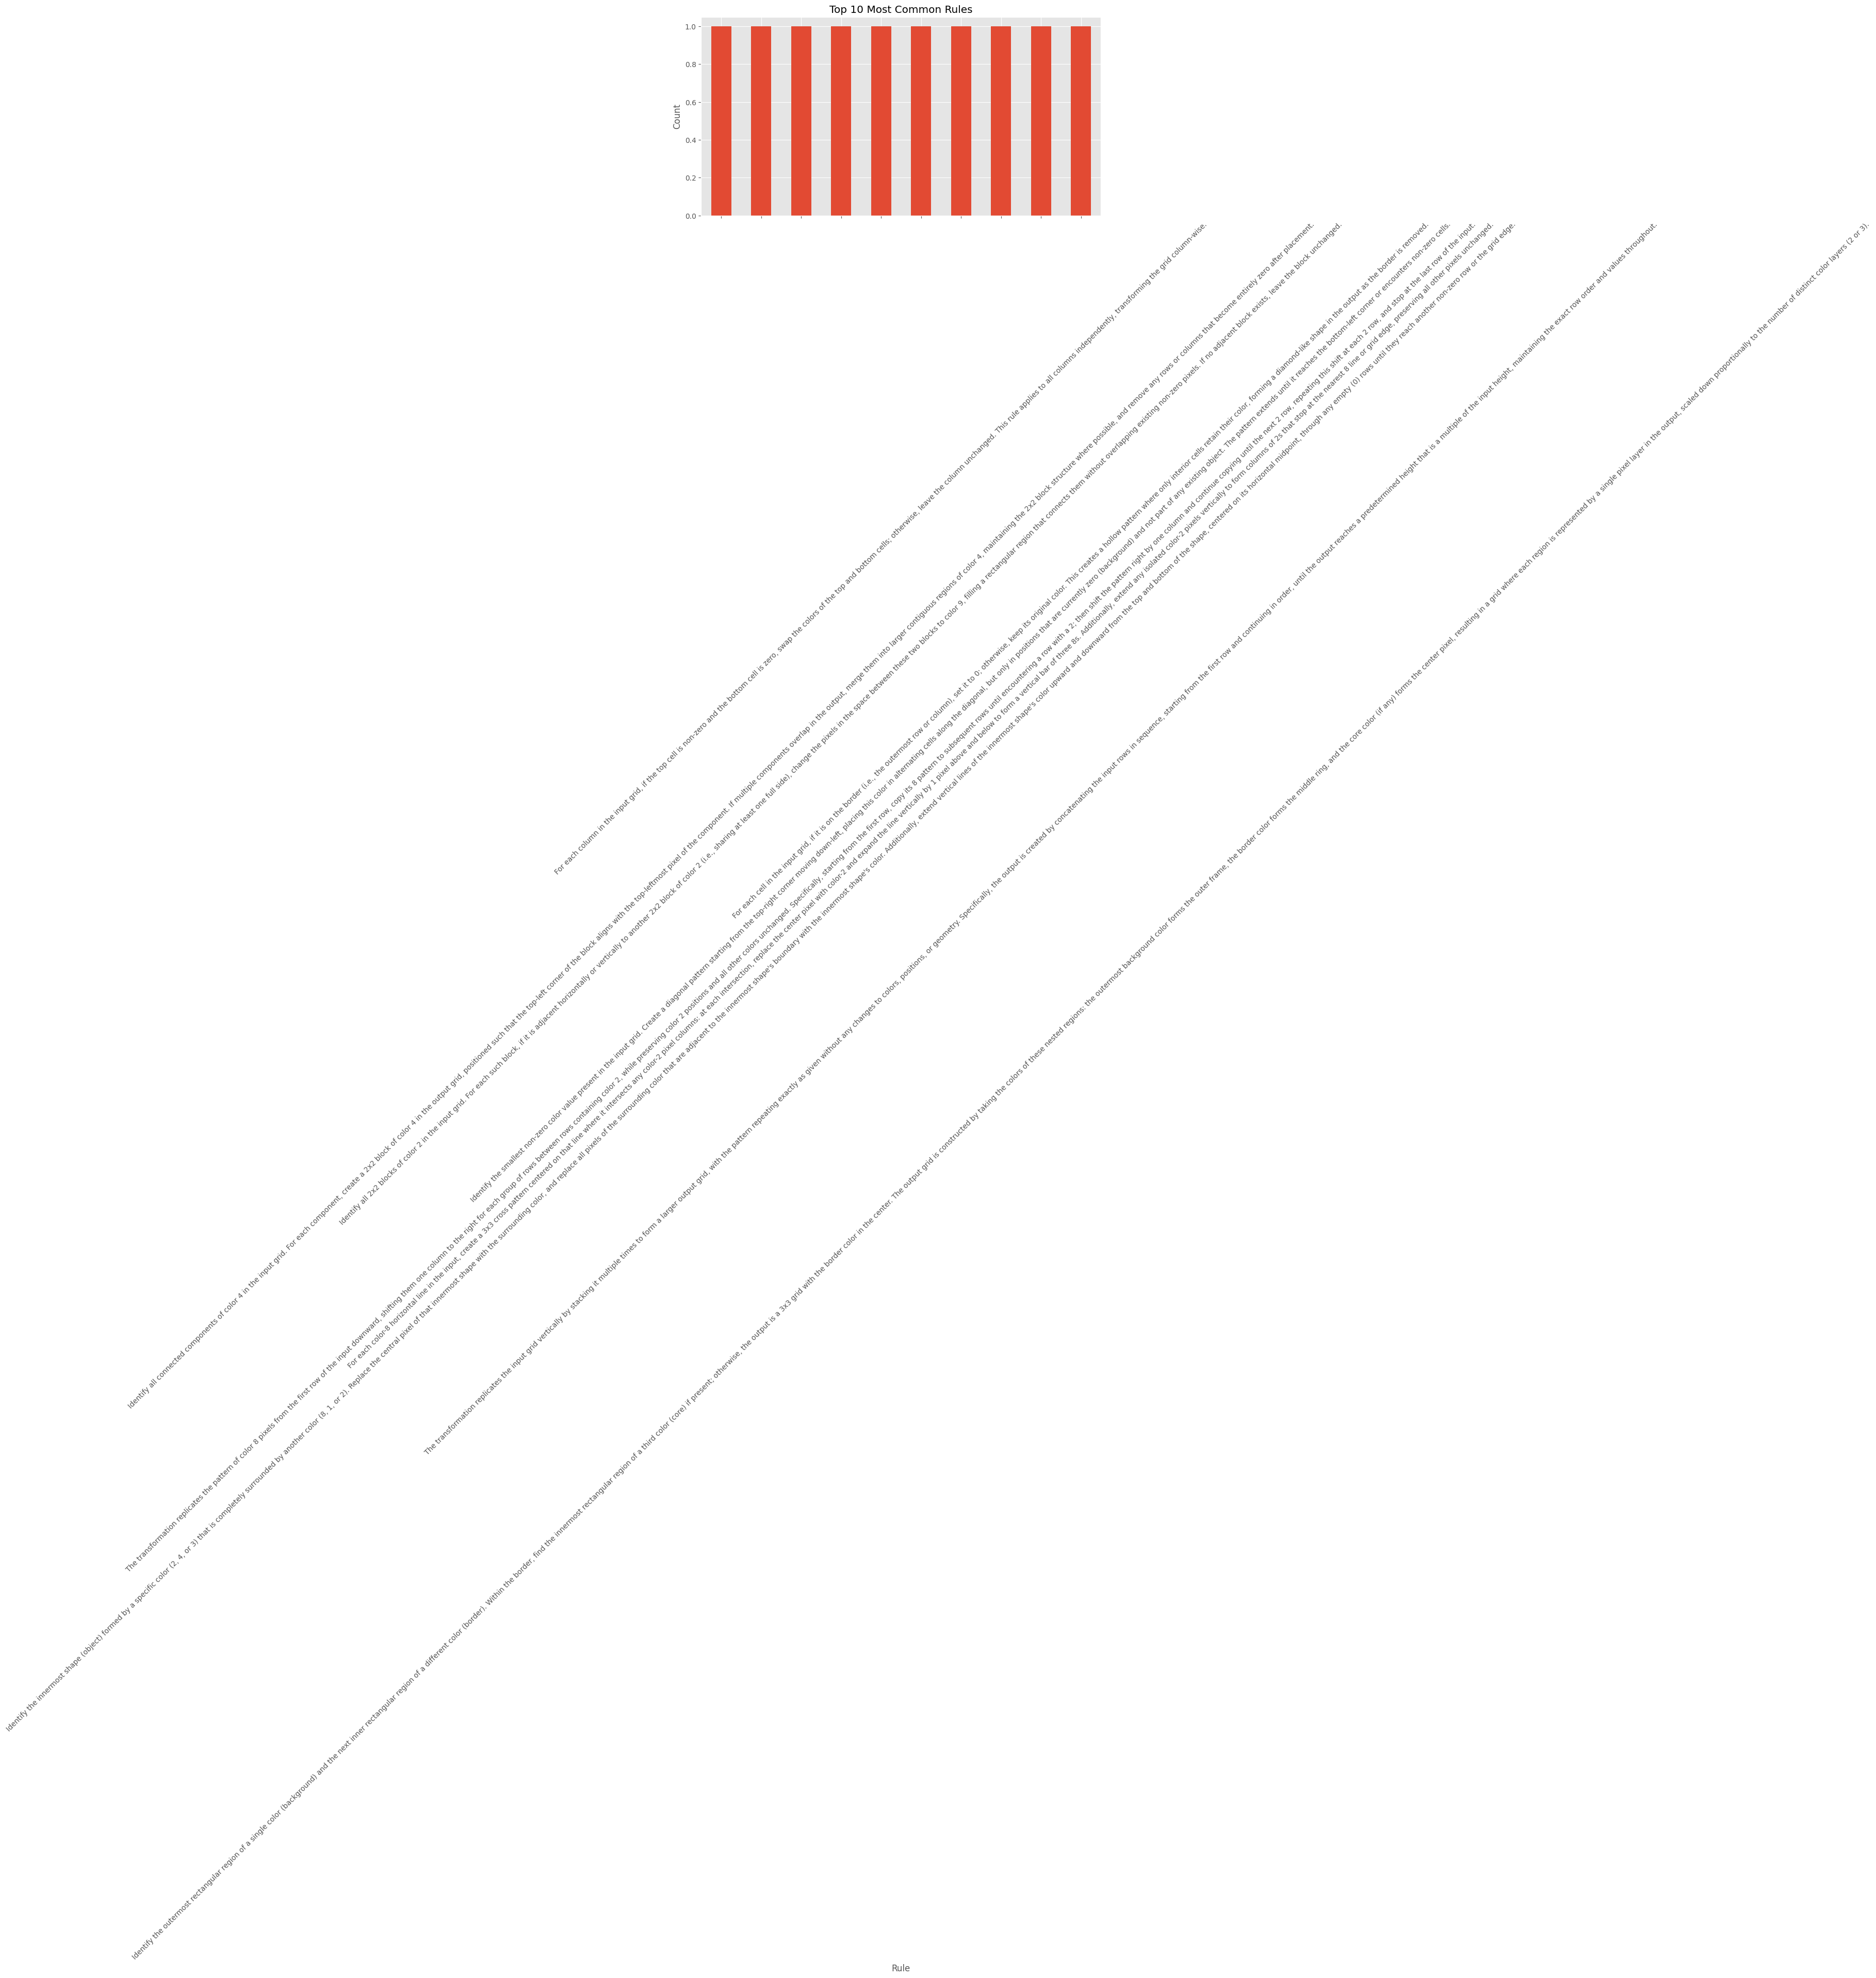

In [9]:
top_rules = df['Short_Rule'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_rules.plot(kind='bar')
plt.title("Top 10 Most Common Rules")
plt.xlabel("Rule")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

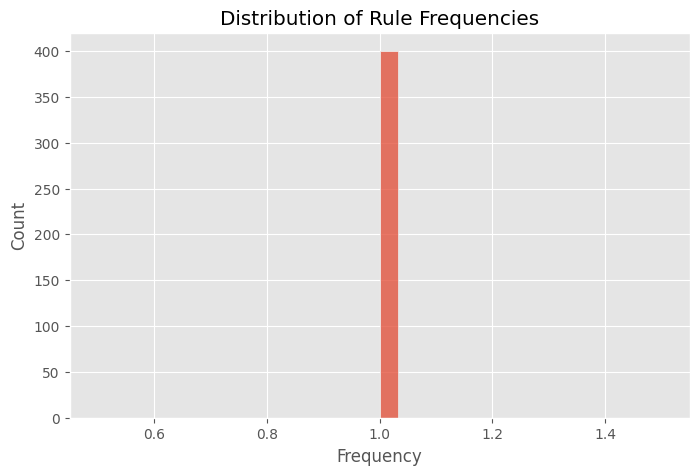

In [10]:
rule_counts = df['Short_Rule'].value_counts()

plt.figure(figsize=(8,5))
sns.histplot(rule_counts, bins=30)
plt.title("Distribution of Rule Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()

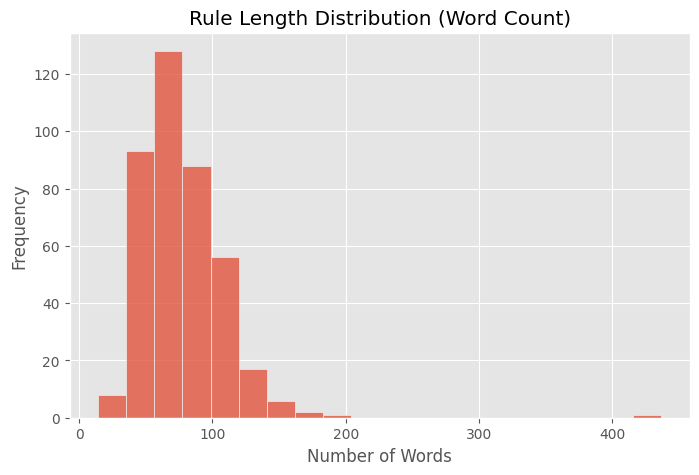

In [11]:
df['rule_length'] = df['Short_Rule'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['rule_length'], bins=20)
plt.title("Rule Length Distribution (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

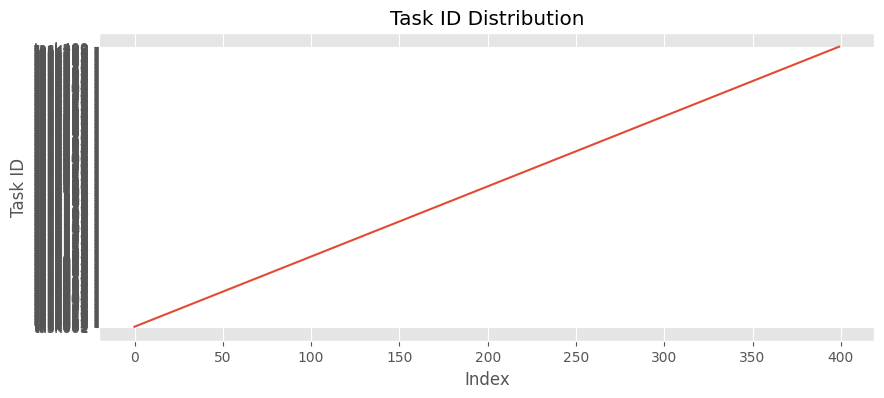

In [12]:
plt.figure(figsize=(10,4))
plt.plot(range(len(df)), df['Task_ID'])
plt.title("Task ID Distribution")
plt.xlabel("Index")
plt.ylabel("Task ID")
plt.show()

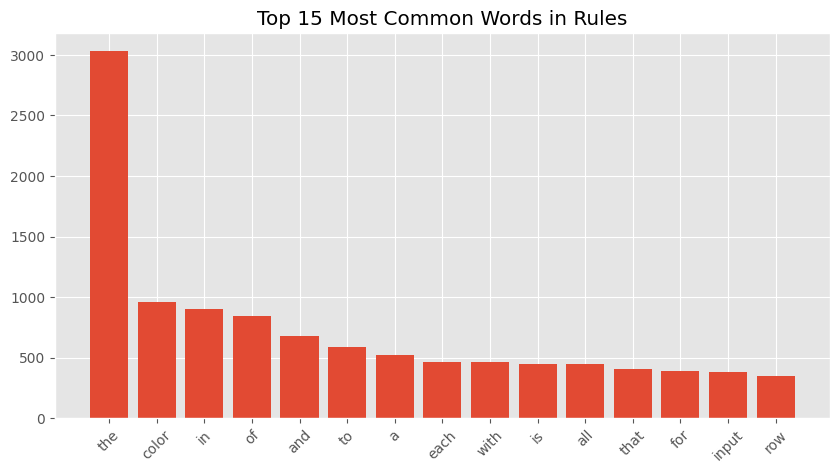

In [13]:
all_words = " ".join(df['Short_Rule'].astype(str)).lower().split()
word_counts = Counter(all_words)

common_words = word_counts.most_common(15)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 15 Most Common Words in Rules")
plt.xticks(rotation=45)
plt.show()

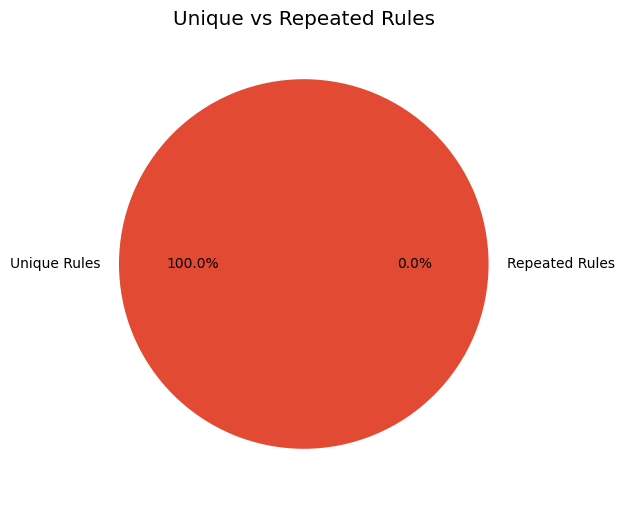

In [14]:
unique_rules = (rule_counts == 1).sum()
repeated_rules = (rule_counts > 1).sum()

plt.figure(figsize=(6,6))
plt.pie([unique_rules, repeated_rules],
        labels=['Unique Rules', 'Repeated Rules'],
        autopct='%1.1f%%')
plt.title("Unique vs Repeated Rules")
plt.show()

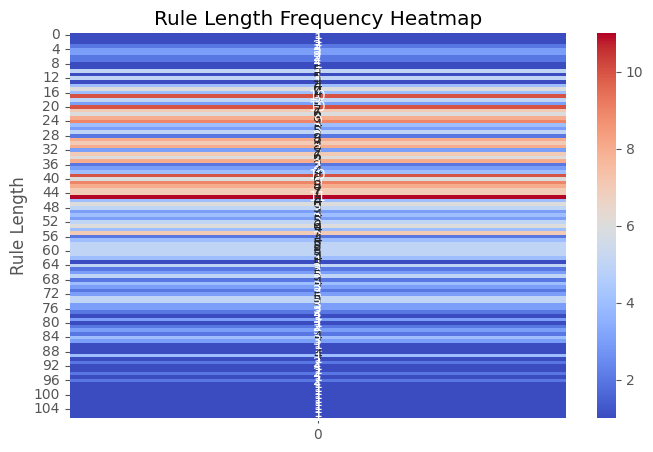

In [15]:
heat_data = df.groupby('rule_length')['Short_Rule'].count()

plt.figure(figsize=(8,5))
sns.heatmap(heat_data.values.reshape(-1,1), annot=True, fmt='d', cmap='coolwarm')
plt.title("Rule Length Frequency Heatmap")
plt.ylabel("Rule Length")
plt.show()

## Feature engineering

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.preprocessing import label_binarize

In [17]:
df = df[['Task_ID', 'Short_Rule']].dropna()
df.reset_index(drop=True, inplace=True)

In [18]:
tfidf_temp = TfidfVectorizer(stop_words='english')
X_temp = tfidf_temp.fit_transform(df['Short_Rule'])

# Create 5 rule categories
kmeans = KMeans(n_clusters=5, random_state=42)
df['target'] = kmeans.fit_predict(X_temp)

print(df[['Short_Rule', 'target']].head())

                                          Short_Rule  target
0  The transformation creates a 9x9 output grid b...       3
1  Identify all interior regions completely surro...       2
2  The transformation duplicates the input grid v...       3
3  Shift each object (connected group of same-col...       4
4  For each distinct non-zero color in the input,...       4


In [19]:
X = df['Short_Rule']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [21]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train_enc)

y_pred_lr = lr_pipeline.predict(X_test)

In [22]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train_enc)

y_pred_rf = rf_pipeline.predict(X_test)

In [23]:
print("Logistic Regression Accuracy:", accuracy_score(y_test_enc, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test_enc, y_pred_rf))

print("\nClassification Report (LR):")
print(classification_report(y_test_enc, y_pred_lr))

Logistic Regression Accuracy: 0.9375
Random Forest Accuracy: 0.8625

Classification Report (LR):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.90      0.90      0.90        21
           2       0.91      1.00      0.95        20
           3       0.94      0.94      0.94        18
           4       1.00      0.95      0.97        20

    accuracy                           0.94        80
   macro avg       0.75      0.76      0.76        80
weighted avg       0.93      0.94      0.93        80



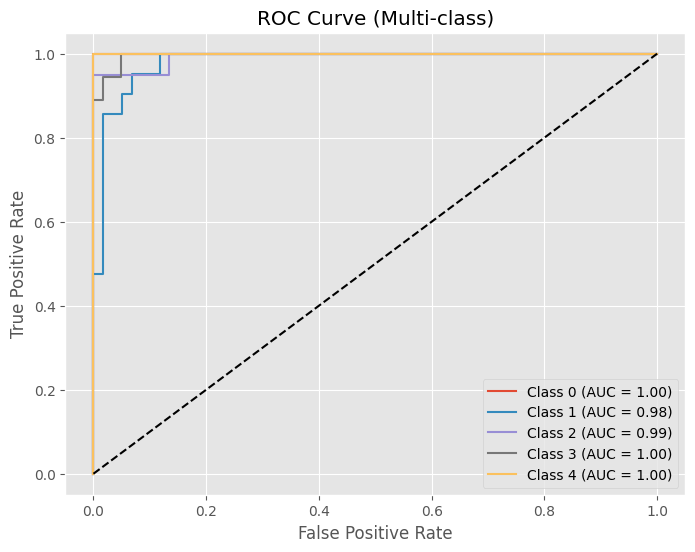

In [24]:
# Binarize labels
classes = np.unique(y_train_enc)
y_test_bin = label_binarize(y_test_enc, classes=classes)

# Predict probabilities
y_prob = lr_pipeline.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

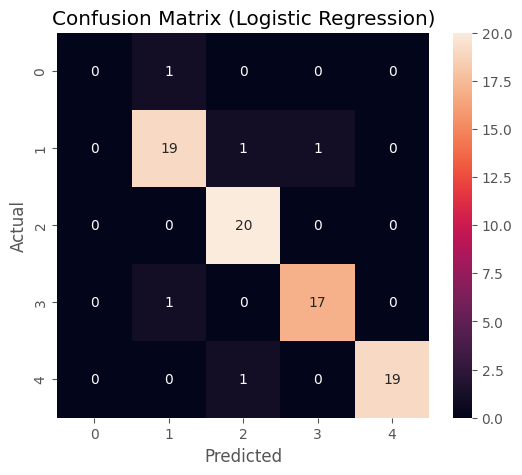

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_enc, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Thank you...pls upvote!!!!